# Smartphones in India, 2023
## Task 3 · Predictive modelling and regression analysis

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

In Task 1 we cleaned the data, and in Task 2 we tested hypotheses. Now we build two models on the clean data (`data/smartphones_clean.csv`, 907 phones):

| Part | Model | Our question | What we predict |
|---|---|---|---|
| A | Multiple linear regression | **What drives the price of a phone?** | the price (in €) |
| B | Binary logistic regression | **Which phones get 5G?** | the probability of 5G ("Yes" or "No") |

**How we cover the requirements**

| Requirement | Where |
|---|---|
| Linear: correlations between the variables | A.2 |
| Linear: coefficients and the regression equation | A.3, A.4 |
| Linear: t-tests for the coefficients and F-test for the whole model | A.5 |
| Linear: MAE, MSE, RMSE, MAPE, R² | A.6 |
| Linear: predictions for new phones | A.7 |
| Logistic: coefficients and the logistic regression equation | B.2, B.3 |
| Logistic: confusion matrix | B.4 |
| Logistic: accuracy, precision, recall, F1-score, ROC-AUC | B.5 |
| Logistic: probability predictions ("No" or "Yes") | B.6 |

We use the significance level **α = 0.05** for all tests.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score,
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, NullLocator, PercentFormatter, StrMethodFormatter
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)
ALPHA = 0.05

# We use the same chart style as in Tasks 1 and 2 (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})

def save(fig, name):
    # We save every chart to figures/ so it can go straight into our slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

df = pd.read_csv(DATA / "smartphones_clean.csv")

# New variables for our models
df["log_price_eur"] = np.log(df["price_eur"])                 # the target of the linear model (Task 1: price is skewed, log fixes it)
df["storage_100gb"] = df["internal_memory"] / 100              # storage in units of 100 GB, easier to interpret
df["is_apple"] = (df["brand_name"] == "apple").astype(int)     # 1 = iPhone, 0 = Android or other
df["is_foldable"] = (df["is_foldable"] == "Yes").astype(int)   # our flag from Task 1, now as 1/0
df["price_100eur"] = df["price_eur"] / 100                     # price in units of 100 EUR, for the logistic model
print(f"{len(df)} phones, {df.shape[1]} columns")

907 phones, 65 columns


### Training and test sets
We fit each model on 80% of the phones (the **training set**) and measure its performance on the other 20% (the **test set**). The models never see the test phones, so the test results show how well they work on new phones, not just how well they remember the old ones.

In [2]:
# The same 80/20 split for both models; random_state makes it repeatable
train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f"All phones: {len(df)} | training set: {len(train)} | test set: {len(test)}")

All phones: 907 | training set: 725 | test set: 182


# Part A · Multiple linear regression: what drives the price of a phone?

## A.1 Our variables
- **Dependent variable:** `log_price_eur`, the logarithm of the price in euros. In Task 1 we saw that the price is strongly right-skewed, and the logarithm makes it almost symmetric, which suits linear regression better. A nice side effect: each coefficient can be read as a **percentage change in price**.
- **Independent variables (predictors):**

| Variable | Meaning | Why we use it |
|---|---|---|
| `processor_speed` | processor speed in GHz | the strongest link with the price in Task 1 (r = 0.81) |
| `ram_capacity` | RAM in GB | r = 0.69 in Task 1 |
| `storage_100gb` | storage in units of 100 GB | r = 0.67 in Task 1 |
| `has_nfc` | 1 = has NFC | a premium feature (Task 2, Test 2) |
| `is_apple` | 1 = iPhone | iPhones cost more for their specs (Task 2, Test 3) |
| `is_foldable` | 1 = foldable phone | our new feature from Task 1: a foldable screen is an expensive design |

**Why not the rating?** In Task 1 we filled the missing ratings using the median of the same *price group*, so the rating partly contains the price itself. Using it to predict the price would be cheating.

In A.6 we also compare our model with a simpler one (one variable) and a bigger one (eleven variables).

## A.2 Correlations between our variables (requirement 1)

In [3]:
lin_vars = ["log_price_eur", "processor_speed", "ram_capacity", "storage_100gb", "has_nfc", "is_apple", "is_foldable"]
corr = train[lin_vars].corr()
corr.style.format("{:.2f}")

,log_price_eur,processor_speed,ram_capacity,storage_100gb,has_nfc,is_apple,is_foldable
log_price_eur,1.00,0.81,0.68,0.67,0.70,0.42,0.32
processor_speed,0.81,1.00,0.60,0.52,0.63,0.35,0.19
ram_capacity,0.68,0.60,1.00,0.55,0.47,-0.10,0.20
storage_100gb,0.67,0.52,0.55,1.00,0.42,0.31,0.26
has_nfc,0.70,0.63,0.47,0.42,1.00,0.28,0.17
is_apple,0.42,0.35,-0.10,0.31,0.28,1.00,-0.03
is_foldable,0.32,0.19,0.20,0.26,0.17,-0.03,1.00


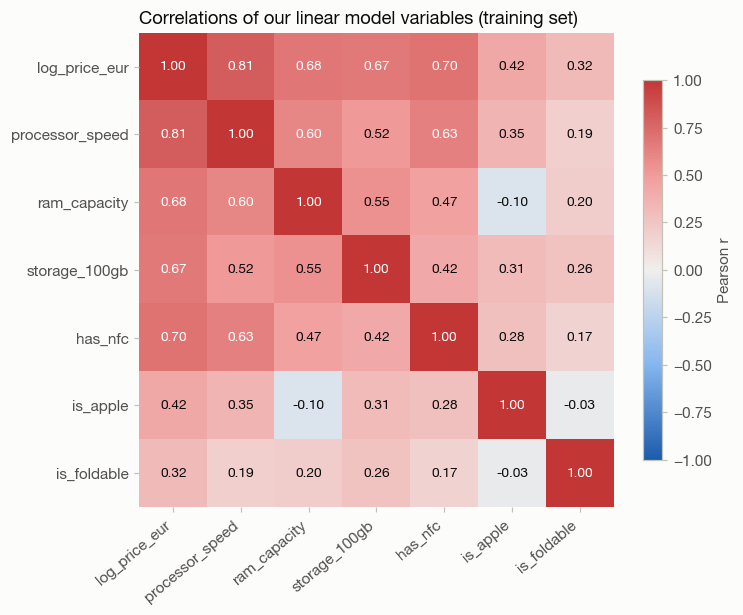

In [4]:
# The same blue-gray-red scale as our correlation matrix in Task 1
diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f19c9b", "#c23736"])
fig, ax = plt.subplots(figsize=(7, 5.6))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(lin_vars)), lin_vars, rotation=40, ha="right")
ax.set_yticks(range(len(lin_vars)), lin_vars)
for i in range(len(lin_vars)):
    for j in range(len(lin_vars)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if abs(v) > 0.6 else INK)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlations of our linear model variables (training set)")
save(fig, "t3_01_correlations")
plt.show()

Processor speed (r = 0.81), NFC (0.70), RAM (0.68) and storage (0.67) all correlate strongly with the log price. Being an iPhone (0.42) or a foldable (0.32) has a weaker correlation, because there are only 40 iPhones and 19 foldables among our 907 phones. As we will see, both still add a lot to the price.

The predictors also correlate with each other (for example, processor speed with NFC, r = 0.63, and with RAM, r = 0.60). This is called **multicollinearity**, and too much of it makes single coefficients unreliable. We check it with the **variance inflation factor (VIF)**: a value below 5 is usually fine.

In [5]:
predictors = ["processor_speed", "ram_capacity", "storage_100gb", "has_nfc", "is_apple", "is_foldable"]
X = train[predictors].assign(const=1.0)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(len(predictors))], index=predictors)
vif.to_frame("VIF").style.format("{:.2f}")

,VIF
processor_speed,2.50
ram_capacity,2.50
storage_100gb,1.88
has_nfc,1.73
is_apple,1.64
is_foldable,1.11


All VIFs are between 1.1 and 2.5, far below 5, so multicollinearity is not a problem in our model.

## A.3 Estimating the coefficients (requirement 2)
We fit the model with ordinary least squares (OLS) on the training set. The full statsmodels summary shows everything at once; below it we pick out the parts we need.

In [6]:
our_formula = "log_price_eur ~ processor_speed + ram_capacity + storage_100gb + has_nfc + is_apple + is_foldable"
lin_model = smf.ols(our_formula, data=train).fit()
print(lin_model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_price_eur   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     683.2
Date:                Wed, 07 Oct 2026   Prob (F-statistic):          7.80e-293
Time:                        11:03:06   Log-Likelihood:                -142.20
No. Observations:                 725   AIC:                             298.4
Df Residuals:                     718   BIC:                             330.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.3711      0.072     

In [7]:
ci = lin_model.conf_int(alpha=ALPHA)
coef = pd.DataFrame({"coefficient": lin_model.params, "std. error": lin_model.bse,
                     "95% CI lower": ci[0], "95% CI upper": ci[1]})
coef

,coefficient,std. error,95% CI lower,95% CI upper
Intercept,3.3711,0.0717,3.2303,3.5120
processor_speed,0.5026,0.0374,0.4292,0.5760
ram_capacity,0.0913,0.0065,0.0785,0.1041
storage_100gb,0.0922,0.0141,0.0646,0.1198
has_nfc,0.3316,0.0295,0.2736,0.3896
is_apple,0.9021,0.0656,0.7733,1.0310
is_foldable,0.7026,0.0787,0.5482,0.8570


## A.4 The regression equation (requirement 3)

In [8]:
b = lin_model.params
print("Our regression equation:\n")
print(f"log(price in EUR) = {b['Intercept']:.4f}"
      f" + {b['processor_speed']:.4f} * processor_speed"
      f" + {b['ram_capacity']:.4f} * ram_capacity"
      f" + {b['storage_100gb']:.4f} * storage_100gb"
      f" + {b['has_nfc']:.4f} * has_nfc"
      f" + {b['is_apple']:.4f} * is_apple"
      f" + {b['is_foldable']:.4f} * is_foldable")
print("\nand the price itself:  price in EUR = e^(log(price in EUR))")

Our regression equation:

log(price in EUR) = 3.3711 + 0.5026 * processor_speed + 0.0913 * ram_capacity + 0.0922 * storage_100gb + 0.3316 * has_nfc + 0.9021 * is_apple + 0.7026 * is_foldable

and the price itself:  price in EUR = e^(log(price in EUR))


**How we read the coefficients.** Our model predicts the *logarithm* of the price, so a coefficient b means: **when this variable goes up by 1, the price is multiplied by e^b**, i.e. it changes by (e^b − 1) × 100%, if all the other variables stay the same.

     +0.1 GHz processor speed: price +5.2%
                    +1 GB RAM: price +9.6%
              +100 GB storage: price +9.7%
          has NFC (vs no NFC): price +39.3%
    is an iPhone (vs Android): price +146.5%
is foldable (vs normal phone): price +101.9%


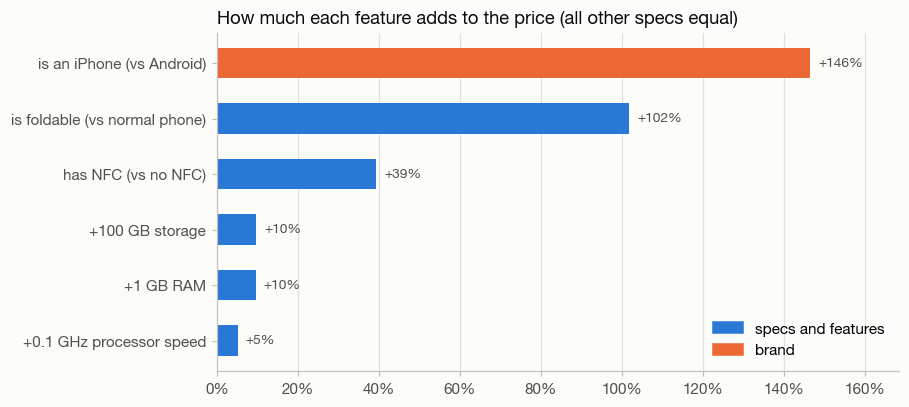

In [9]:
units = {"processor_speed": "+0.1 GHz processor speed", "ram_capacity": "+1 GB RAM", "storage_100gb": "+100 GB storage",
         "has_nfc": "has NFC (vs no NFC)", "is_apple": "is an iPhone (vs Android)",
         "is_foldable": "is foldable (vs normal phone)"}
steps = {"processor_speed": 0.1, "ram_capacity": 1, "storage_100gb": 1, "has_nfc": 1, "is_apple": 1, "is_foldable": 1}
effects = pd.Series({units[v]: np.exp(b[v] * steps[v]) - 1 for v in predictors}) * 100
for name, value in effects.items():
    print(f"{name:>29}: price {value:+.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
order = effects.sort_values()
colors = [ORANGE if name == units["is_apple"] else BLUE for name in order.index]
ax.barh(order.index, order.values, height=0.55, color=colors)
for y, value in enumerate(order.values):
    ax.text(value + 2, y, f"+{value:.0f}%", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, order.max() * 1.15)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=BLUE, label="specs and features"), Patch(color=ORANGE, label="brand")], loc="lower right")
ax.set_title("How much each feature adds to the price (all other specs equal)")
save(fig, "t3_02_price_effects")
plt.show()

- **Specs:** each extra 0.1 GHz of processor speed adds 5.2% to the price, each extra GB of RAM 9.6%, and each extra 100 GB of storage 9.7%.
- **NFC** adds 39%. It's a sign of a better-equipped phone (Task 2, Test 2).
- A **foldable** phone costs 102% more: about **twice as much** as a normal phone with the same specs.
- An **iPhone** costs 146% more than an Android phone with the same specs: **2.5 times the price**. This confirms Task 2 (Test 3): with iPhones, you also pay for the brand.

## A.5 Significance tests (requirement 4)
**t-test for each coefficient.** For every predictor:

$\begin{cases}
H_0: \beta_j = 0 \quad \text{(the variable has no effect on the price)} \\
H_1: \beta_j \neq 0
\end{cases}$

**F-test for the whole model:**

$\begin{cases}
H_0: \beta_1 = \beta_2 = \dots = \beta_6 = 0 \quad \text{(the model explains nothing)} \\
H_1: \text{at least one } \beta_j \neq 0
\end{cases}$

In [10]:
t_tests = pd.DataFrame({"coefficient": lin_model.params, "t": lin_model.tvalues, "p-value": lin_model.pvalues})
t_tests["decision (α = 0.05)"] = np.where(t_tests["p-value"] < ALPHA, "Reject H0: significant", "Do not reject H0")
display(t_tests.drop(index="Intercept").style.format({"coefficient": "{:.4f}", "t": "{:.2f}", "p-value": "{:.2e}"}))

print(f"F-test: F = {lin_model.fvalue:.2f}, df = ({lin_model.df_model:.0f}, {lin_model.df_resid:.0f}), "
      f"p-value = {lin_model.f_pvalue:.3g}, alpha = {ALPHA}")
print("Decision:", "Reject H0: the model as a whole is significant" if lin_model.f_pvalue < ALPHA
      else "Do not reject H0: the model explains nothing")

,coefficient,t,p-value,decision (α = 0.05)
processor_speed,0.5026,13.44,6.82e-37,Reject H0: significant
ram_capacity,0.0913,14.02,1.24e-39,Reject H0: significant
storage_100gb,0.0922,6.55,1.08e-10,Reject H0: significant
has_nfc,0.3316,11.22,4.79e-27,Reject H0: significant
is_apple,0.9021,13.75,2.44e-38,Reject H0: significant
is_foldable,0.7026,8.93,3.46e-18,Reject H0: significant


F-test: F = 683.23, df = (6, 718), p-value = 7.8e-293, alpha = 0.05
Decision: Reject H0: the model as a whole is significant


**Conclusion.** For all six predictors p < 0.001 < α = 0.05, so **we reject H₀ for every coefficient**: each variable has a significant effect on the price, even when the other five are in the model. The F-test gives F = 683.2 with p < 0.001, so **we also reject H₀ for the whole model**. Together, our six variables explain **85.1%** of the variation in log price in the training set (R² = 0.851, adjusted R² = 0.850).

## A.6 Performance metrics (requirement 5)
We compare the predicted prices with the real ones. Our model predicts log(price), so we turn its predictions back into euros with e^x and compute the errors in euros:
- **MAE** (mean absolute error): the average size of the error, in €.
- **MSE** (mean squared error): the average squared error; it punishes large errors more.
- **RMSE** (root mean squared error): √MSE, back in €.
- **MAPE** (mean absolute percentage error): the average error as a % of the real price.
- **R²** (coefficient of determination): the share of the variation in price that the model explains. We show it for the log price (what the model predicts) and for the price in €.

In [11]:
def regression_metrics(data):
    actual = data["price_eur"]
    predicted = np.exp(lin_model.predict(data))
    mse = mean_squared_error(actual, predicted)
    return {"MAE (EUR)": mean_absolute_error(actual, predicted), "MSE (EUR²)": mse, "RMSE (EUR)": np.sqrt(mse),
            "MAPE": mean_absolute_percentage_error(actual, predicted),
            "R² (log price)": r2_score(data["log_price_eur"], lin_model.predict(data)),
            "R² (price in EUR)": r2_score(actual, predicted)}

metrics = pd.DataFrame({"training set": regression_metrics(train), "test set": regression_metrics(test)})
(metrics.style.format("{:.3f}")
        .format("{:,.1f}", subset=pd.IndexSlice[["MAE (EUR)", "RMSE (EUR)"], :])
        .format("{:,.0f}", subset=pd.IndexSlice[["MSE (EUR²)"], :])
        .format("{:.1%}", subset=pd.IndexSlice[["MAPE"], :]))

,training set,test set
MAE (EUR),89.1,81.1
MSE (EUR²),"27,694","21,129"
RMSE (EUR),166.4,145.4
MAPE,22.9%,24.8%
R² (log price),0.851,0.832
R² (price in EUR),0.749,0.753


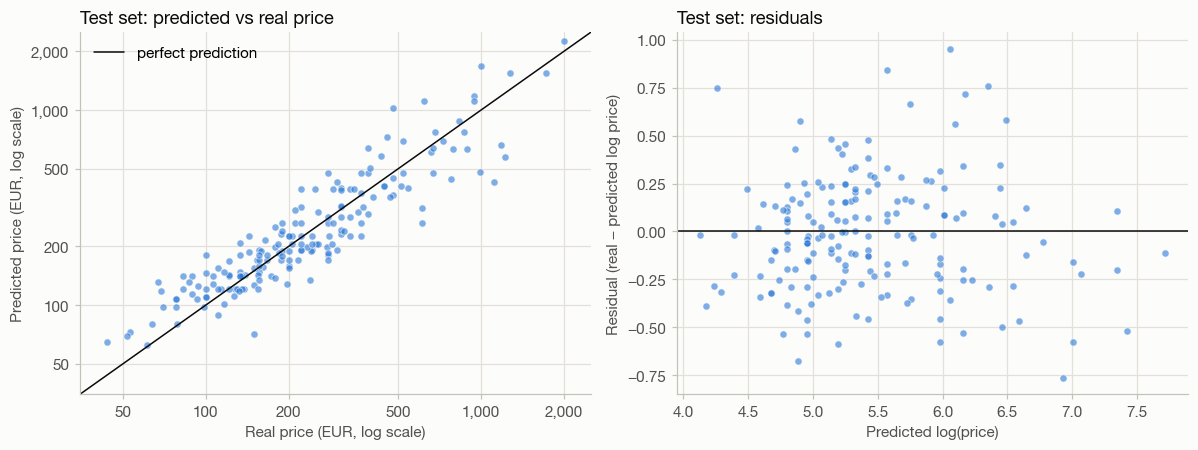

In [12]:
pred_log_test = lin_model.predict(test)
residuals = test["log_price_eur"] - pred_log_test

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.scatter(test["price_eur"], np.exp(pred_log_test), s=22, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.6)
lims = [35, 2500]
ax.plot(lims, lims, color=INK, linewidth=1, label="perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims); ax.set_ylim(lims)
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(FixedLocator([50, 100, 200, 500, 1000, 2000]))
    axis.set_minor_locator(NullLocator())
    axis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Real price (EUR, log scale)")
ax.set_ylabel("Predicted price (EUR, log scale)")
ax.set_title("Test set: predicted vs real price")
ax.legend(loc="upper left")

ax = axes[1]
ax.scatter(pred_log_test, residuals, s=22, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.6)
ax.axhline(0, color=INK, linewidth=1)
ax.set_xlabel("Predicted log(price)")
ax.set_ylabel("Residual (real − predicted log price)")
ax.set_title("Test set: residuals")
fig.tight_layout()
save(fig, "t3_03_predicted_vs_real")
plt.show()

In [13]:
# Our biggest misses on the test set: phones much more expensive (top) or much cheaper (bottom) than predicted
misses = test.assign(predicted_eur=np.exp(pred_log_test), residual=residuals)
(pd.concat([misses.nlargest(3, "residual"), misses.nsmallest(2, "residual")])
   [["model", "price_eur", "predicted_eur", "ram_capacity", "residual"]]
   .rename(columns={"price_eur": "real price", "predicted_eur": "predicted price", "residual": "residual (log)"})
   .style.format({"real price": "€{:,.0f}", "predicted price": "€{:,.0f}", "ram_capacity": "{:.0f} GB",
                  "residual (log)": "{:+.2f}"}).hide(axis="index"))

model,real price,predicted price,ram_capacity,residual (log)
Samsung Galaxy S22 Ultra 5G (8GB RAM + 128GB),"€1,111",€428,8 GB,+0.95
LG Velvet 5G,€611,€264,6 GB,+0.84
Royole FlexPai 2,"€1,222",€572,8 GB,+0.76
OPPO Reno 10 Pro,€478,"€1,025",16 GB,-0.76
Letv Y1 Pro Plus,€67,€132,6 GB,-0.68


- On the **test set**, our predictions are on average **€81 away** from the real price (MAE), which is **25%** of the price (MAPE).
- **RMSE (€145) is almost twice the MAE.** RMSE squares the errors, so a few large errors on expensive phones push it up.
- **R² = 0.83** for the log price: on new phones, our model explains 83% of the variation. For the price in € it is 0.75, lower because the few large errors are on expensive phones, where errors in euros are big.
- The training and test results are close (R² 0.85 vs 0.83, MAE €89 vs €81), so our model is **not overfitting**: it works about as well on new phones as on the phones it learned from.
- In the left chart, the points follow the diagonal well. Our biggest misses (table above) are phones that cost much more than their specs suggest: Samsung's Galaxy S22 Ultra (€1,111, while our model predicts €428), the LG Velvet and the foldable Royole FlexPai 2. In the other direction, the OPPO Reno 10 Pro has 16 GB of RAM but costs only €478 (predicted: €1,025). In the right chart, the residuals are spread around 0 without a clear pattern.

**Can we trust the t- and F-tests from A.5?** They assume that the residuals are roughly normal and have the same spread everywhere. Our residual plot shows a few phones that are much more expensive than their specs suggest, so the residuals have a longer right tail (the Jarque–Bera test in the summary in A.3 rejects normality). With 725 phones in the training set this matters little, because by the central limit theorem the coefficients are still close to normally distributed. To check the spread, we use the Breusch–Pagan test (H₀: the spread is the same everywhere), and then repeat the t-tests with *robust* (HC3) standard errors, which don't need the same spread.

In [14]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_p = het_breuschpagan(lin_model.resid, lin_model.model.exog)[1]
print(f"Breusch-Pagan test: p-value = {bp_p:.2g} ->", "Reject H0: the spread is not constant" if bp_p < ALPHA
      else "Do not reject H0: the spread is constant")

robust = smf.ols(our_formula, data=train).fit(cov_type="HC3")
(pd.DataFrame({"t (usual)": lin_model.tvalues, "t (robust)": robust.tvalues, "p-value (robust)": robust.pvalues})
   .drop(index="Intercept").style.format({"t (usual)": "{:.2f}", "t (robust)": "{:.2f}", "p-value (robust)": "{:.2e}"}))

Breusch-Pagan test: p-value = 4.2e-06 -> Reject H0: the spread is not constant


,t (usual),t (robust),p-value (robust)
processor_speed,13.44,12.78,2.21e-37
ram_capacity,14.02,11.29,1.49e-29
storage_100gb,6.55,5.27,1.33e-07
has_nfc,11.22,10.62,2.51e-26
is_apple,13.75,12.10,1.06e-33
is_foldable,8.93,6.39,1.71e-10


The Breusch–Pagan test rejects H₀ (p < 0.001): the spread of the errors is not exactly the same for all phones. But with robust standard errors every t-value is still above 5 and every p-value below 0.001, so **all our conclusions from A.5 stay the same**.

**Do the values we filled in Task 1 change the result?** In Task 1 we filled the missing processor speeds with the median of the same chip family, and we flagged them so we could check our results without them. So we fit the same model again, only on the phones with a measured processor speed:

In [15]:
measured = train[~train["processor_speed_imputed"]]
measured_model = smf.ols(our_formula, data=measured).fit()
filled = train[train["processor_speed_imputed"]]
print(f"Training phones with a measured speed: {len(measured)} of {len(train)} "
      f"(we filled {len(filled)} speeds in Task 1, {filled['is_apple'].sum()} of them for iPhones)\n")

effect = lambda model: pd.Series({v: (np.exp(model.params[v] * steps[v]) - 1) * 100 for v in predictors})
(pd.DataFrame({"price effect, all phones": effect(lin_model), "price effect, measured speed only": effect(measured_model),
               "p-value, measured speed only": measured_model.pvalues[predictors]})
   .rename(index=units).style.format({"price effect, all phones": "{:+.1f}%", "price effect, measured speed only": "{:+.1f}%",
                                      "p-value, measured speed only": "{:.2e}"}))

Training phones with a measured speed: 697 of 725 (we filled 28 speeds in Task 1, 10 of them for iPhones)



,"price effect, all phones","price effect, measured speed only","p-value, measured speed only"
+0.1 GHz processor speed,+5.2%,+5.2%,6.29e-38
+1 GB RAM,+9.6%,+8.9%,1.59e-32
+100 GB storage,+9.7%,+10.8%,9.17e-10
has NFC (vs no NFC),+39.3%,+39.6%,5.53e-27
is an iPhone (vs Android),+146.5%,+125.2%,9.56e-27
is foldable (vs normal phone),+101.9%,+102.0%,2.70e-18


Almost nothing changes: all six effects stay significant (p < 0.001), and five of them move by at most 1.1 percentage points. Only the iPhone effect drops, from +146% to +125%. The reason: 10 of the 28 phones we leave out are iPhones, and they are the newest and most expensive ones (the iPhone 14 Pro, 14 Pro Max and the iPhone 15 series), whose processor speeds were missing. Either way, **an iPhone costs more than twice as much as an Android phone with the same specs**, so our conclusion stays the same.

**Is our model the right size?** We compare it with a *simple* linear regression (processor speed only) and with a *bigger* model that adds five more variables: screen size, battery, refresh rate, 5G and the main camera.

In [16]:
def evaluate(formula):
    model = smf.ols(formula, data=train).fit()
    predicted = np.exp(model.predict(test))
    return {"variables": int(model.df_model), "adjusted R² (training)": model.rsquared_adj,
            "R² (test, log price)": r2_score(test["log_price_eur"], model.predict(test)),
            "MAE (test, EUR)": mean_absolute_error(test["price_eur"], predicted),
            "MAPE (test)": mean_absolute_percentage_error(test["price_eur"], predicted)}

simple_model = smf.ols("log_price_eur ~ processor_speed", data=train).fit()
print(f"Simple model: log(price in EUR) = {simple_model.params['Intercept']:.4f} "
      f"+ {simple_model.params['processor_speed']:.4f} * processor_speed\n")

comparison = pd.DataFrame({
    "simple (processor speed only)": evaluate("log_price_eur ~ processor_speed"),
    "ours (6 variables)": evaluate(our_formula),
    "bigger (11 variables)": evaluate(our_formula + " + screen_size + battery_capacity + refresh_rate"
                                                    " + has_5g + primary_camera_rear"),
}).T
comparison.style.format({"variables": "{:.0f}", "adjusted R² (training)": "{:.3f}", "R² (test, log price)": "{:.3f}",
                         "MAE (test, EUR)": "{:.1f}", "MAPE (test)": "{:.1%}"})

Simple model: log(price in EUR) = 2.2624 + 1.3336 * processor_speed



,variables,adjusted R² (training),"R² (test, log price)","MAE (test, EUR)",MAPE (test)
simple (processor speed only),1,0.660,0.637,118.0,38.2%
ours (6 variables),6,0.850,0.832,81.1,24.8%
bigger (11 variables),11,0.860,0.849,75.5,22.9%


- **Processor speed alone** (a simple linear regression) explains 64% of the variation in log price on the test set, with an average error of €118 (38%).
- **Our six variables** raise this to 83% and cut the average error to €81 (25%).
- **Five more variables** raise R² only to 0.85 and cut the error by less than €6. Two of them (screen size and refresh rate) are not even significant (p > 0.05), and a bigger battery even gets a negative coefficient, because cheap phones often have the biggest batteries.

So we keep our six-variable model: it is almost as accurate as the bigger one, and every coefficient is significant and easy to explain.

## A.7 Predictions for new phones (requirement 6)
We describe five new phones that are not in our data and let our model predict their prices. The last three have exactly the same specs, so we can see what the brand and the design add. Besides the predicted price, we show the **95% prediction interval**: the range where the price of such a phone should fall with 95% probability.

In [17]:
new_phones = pd.DataFrame({
    "phone": ["Budget phone", "Mid-range phone", "Premium Android phone", "iPhone with the same specs",
              "Foldable with the same specs"],
    "processor_speed": [2.0, 2.4, 3.2, 3.2, 3.2],
    "ram_capacity": [4, 6, 8, 8, 8],
    "storage_100gb": [0.64, 1.28, 2.56, 2.56, 2.56],
    "has_nfc": [0, 0, 1, 1, 1],
    "is_apple": [0, 0, 0, 1, 0],
    "is_foldable": [0, 0, 0, 0, 1],
})
prediction = lin_model.get_prediction(new_phones).summary_frame(alpha=ALPHA)
result = new_phones.assign(storage_gb=new_phones["storage_100gb"] * 100).drop(columns="storage_100gb")
result["predicted price (EUR)"] = np.exp(prediction["mean"])
result["95% interval: from"] = np.exp(prediction["obs_ci_lower"])
result["95% interval: to"] = np.exp(prediction["obs_ci_upper"])
result["predicted price (INR)"] = result["predicted price (EUR)"] * 90
result.style.format({"processor_speed": "{:.1f}", "storage_gb": "{:.0f}", "predicted price (EUR)": "€{:,.0f}",
                     "95% interval: from": "€{:,.0f}", "95% interval: to": "€{:,.0f}",
                     "predicted price (INR)": "₹{:,.0f}"}).hide(axis="index")

phone,processor_speed,ram_capacity,has_nfc,is_apple,is_foldable,storage_gb,predicted price (EUR),95% interval: from,95% interval: to,predicted price (INR)
Budget phone,2.0,4,0,0,0,64,€122,€68,€218,"₹10,942"
Mid-range phone,2.4,6,0,0,0,128,€189,€106,€339,"₹17,035"
Premium Android phone,3.2,8,1,0,0,256,€532,€297,€955,"₹47,924"
iPhone with the same specs,3.2,8,1,1,0,256,"€1,312",€727,"€2,368","₹118,124"
Foldable with the same specs,3.2,8,1,0,1,256,"€1,075",€590,"€1,958","₹96,758"


- A **budget phone** (2.0 GHz, 4 GB RAM, 64 GB) should cost about **€122** (₹10,900), and a **mid-range phone** (2.4 GHz, 6 GB, 128 GB) about **€189** (₹17,000).
- A **premium Android phone** (3.2 GHz, 8 GB, 256 GB, NFC) should cost about **€532**.
- **With exactly the same specs**, an **iPhone** should cost **€1,312** and a **foldable €1,075**: two to two and a half times as much.
- The 95% prediction intervals are wide (for the premium Android phone, €297 to €955). The specs explain most of the price, but not all of it: the camera quality, the design or the release date also matter.

## A.8 Conclusion of Part A

**What drives the price of a phone?** Our multiple linear regression with six variables:

log(price in €) = 3.3711 + 0.5026 · processor_speed + 0.0913 · ram_capacity + 0.0922 · storage_100gb + 0.3316 · has_nfc + 0.9021 · is_apple + 0.7026 · is_foldable

- All six coefficients are significant (t-tests), and so is the whole model (F-test), with p < 0.001 at α = 0.05.
- On new phones, the model explains **83%** of the variation in log price (R² = 0.83), with an average error of **€81 (25%)**.
- **The specs drive the price:** a faster processor, more RAM and more storage make a phone more expensive, and NFC adds 39%.
- **Two things matter more than any single spec:** a foldable screen (×2.0) and the Apple logo (×2.5). This confirms our answer from Task 2: for most phones you pay for the specs, but for iPhones you also pay for the brand.

# Part B · Binary logistic regression: which phones get 5G?

## B.1 Our variables
- **Dependent variable:** `has_5g` (1 = "Yes", 0 = "No"). 55% of the phones have 5G, so the two groups have similar sizes.
- **Independent variables:** in Task 1 we saw that 5G phones are more expensive and have faster chips, and in Task 2 that 5G depends on the price, not on the brand. A smoother screen (higher refresh rate) is another sign of a newer phone. So we use:

| Variable | Meaning |
|---|---|
| `price_100eur` | price in units of €100 |
| `processor_speed` | processor speed in GHz |
| `refresh_rate` | screen refresh rate in Hz (60, 90, 120, …) |

We give the price in units of €100 so the coefficient is easy to explain: what happens to the chance of 5G when a phone costs €100 more. First, a quick look at how 5G and non-5G phones differ (medians, training set):

In [18]:
(train.groupby("has_5g_label")[["price_eur", "processor_speed", "refresh_rate"]].median().rename_axis("has 5G")
      .style.format({"price_eur": "€{:,.0f}", "processor_speed": "{:.2f} GHz", "refresh_rate": "{:.0f} Hz"}))

,price_eur,processor_speed,refresh_rate
has 5G,,,
No,€142,2.05 GHz,60 Hz
Yes,€333,2.84 GHz,120 Hz


## B.2 Estimating the coefficients (requirement 1)
We fit the model with maximum likelihood on the training set. For each coefficient, statsmodels also runs a z-test (H₀: β = 0). The **LLR p-value** at the top of the summary tests the whole model, like the F-test in linear regression (H₀: all coefficients are 0).

In [19]:
log_model = smf.logit("has_5g ~ price_100eur + processor_speed + refresh_rate", data=train).fit(disp=0)
print(log_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 has_5g   No. Observations:                  725
Model:                          Logit   Df Residuals:                      721
Method:                           MLE   Df Model:                            3
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.4798
Time:                        11:03:07   Log-Likelihood:                -259.88
converged:                       True   LL-Null:                       -499.61
Covariance Type:            nonrobust   LLR p-value:                1.341e-103
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -11.0486      1.095    -10.090      0.000     -13.195      -8.902
price_100eur        0.2605      0.091      2.859      0.004       0.082       0.439
processor_speed     2.8131      

In [20]:
log_coef = pd.DataFrame({"coefficient": log_model.params, "z": log_model.tvalues, "p-value": log_model.pvalues,
                         "odds ratio (e^b)": np.exp(log_model.params)})
log_coef["decision (α = 0.05)"] = np.where(log_coef["p-value"] < ALPHA, "Reject H0: significant", "Do not reject H0")
display(log_coef.style.format({"coefficient": "{:.4f}", "z": "{:.2f}", "p-value": "{:.2e}", "odds ratio (e^b)": "{:.4g}"}))
print(f"Whole model (likelihood ratio test): LLR p-value = {log_model.llr_pvalue:.3g}, alpha = {ALPHA}")
print("Decision:", "Reject H0: the model as a whole is significant" if log_model.llr_pvalue < ALPHA
      else "Do not reject H0: the model explains nothing")

,coefficient,z,p-value,odds ratio (e^b),decision (α = 0.05)
Intercept,-11.0486,-10.09,6.15e-24,1.591e-05,Reject H0: significant
price_100eur,0.2605,2.86,4.25e-03,1.298,Reject H0: significant
processor_speed,2.8131,5.67,1.43e-08,16.66,Reject H0: significant
refresh_rate,0.0439,9.12,7.54e-20,1.045,Reject H0: significant


Whole model (likelihood ratio test): LLR p-value = 1.34e-103, alpha = 0.05
Decision: Reject H0: the model as a whole is significant


## B.3 The logistic regression equation (requirement 2)

In [21]:
c = log_model.params
print("Our logistic regression equation:\n")
print(f"logit(p) = ln(p / (1 - p)) = {c['Intercept']:.4f}"
      f" + {c['price_100eur']:.4f} * price_100eur"
      f" + {c['processor_speed']:.4f} * processor_speed"
      f" + {c['refresh_rate']:.4f} * refresh_rate")
print(f"\np = P(5G = Yes) = 1 / (1 + e^-({c['Intercept']:.4f} + {c['price_100eur']:.4f} * price_100eur"
      f" + {c['processor_speed']:.4f} * processor_speed + {c['refresh_rate']:.4f} * refresh_rate))")

print("\nWhat the odds ratios mean (all other variables stay the same):")
print(f"  +100 EUR of price           -> the odds of 5G are multiplied by {np.exp(c['price_100eur']):.2f}")
print(f"  +0.1 GHz processor speed    -> the odds of 5G are multiplied by {np.exp(0.1 * c['processor_speed']):.2f}")
print(f"  90 Hz screen instead of 60  -> the odds of 5G are multiplied by {np.exp(30 * c['refresh_rate']):.2f}")

Our logistic regression equation:

logit(p) = ln(p / (1 - p)) = -11.0486 + 0.2605 * price_100eur + 2.8131 * processor_speed + 0.0439 * refresh_rate

p = P(5G = Yes) = 1 / (1 + e^-(-11.0486 + 0.2605 * price_100eur + 2.8131 * processor_speed + 0.0439 * refresh_rate))

What the odds ratios mean (all other variables stay the same):
  +100 EUR of price           -> the odds of 5G are multiplied by 1.30
  +0.1 GHz processor speed    -> the odds of 5G are multiplied by 1.32
  90 Hz screen instead of 60  -> the odds of 5G are multiplied by 3.73


Here **p** is the probability that a phone has 5G, and **p / (1 − p)** are the *odds* (for example, p = 0.8 means odds of 4 to 1). The logistic function turns any value of the equation into a probability between 0 and 1.

- **Price:** each extra €100 multiplies the odds of 5G by **1.30** (+30%).
- **Processor speed:** each extra 0.1 GHz multiplies the odds by **1.32** (+32%).
- **Refresh rate:** a 90 Hz screen instead of a 60 Hz one multiplies the odds by **3.73**.

All three coefficients are positive and significant (every p ≤ 0.004 < α = 0.05), and so is the whole model (LLR p < 0.001). A fast screen doesn't bring 5G by itself, of course: it is a sign of a newer, better-equipped phone, and newer phones more often have 5G.

## B.4 Confusion matrix (requirement 3)
We predict "Yes" (5G) when the probability is at least 0.5, and compare our predictions with reality on the **test set**.

In [22]:
prob_test = log_model.predict(test)
pred_label = (prob_test >= 0.5).astype(int)
cm = confusion_matrix(test["has_5g"], pred_label)
tn, fp, fn, tp = cm.ravel()
print(f"True negatives = {tn} | False positives = {fp} | False negatives = {fn} | True positives = {tp}")
pd.DataFrame(cm, index=["Actual: No", "Actual: Yes"], columns=["Predicted: No", "Predicted: Yes"])

True negatives = 68 | False positives = 10 | False negatives = 16 | True positives = 88


,Predicted: No,Predicted: Yes
Actual: No,68,10
Actual: Yes,16,88


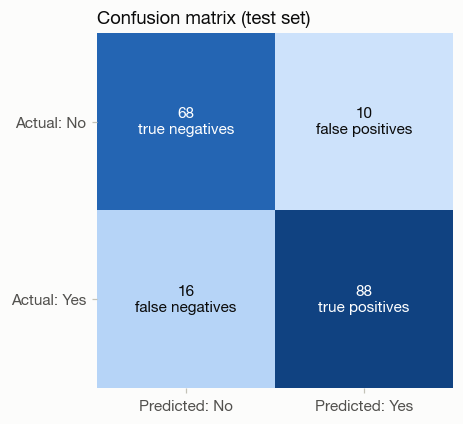

In [23]:
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#104281"])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.imshow(cm, cmap=blues)
labels = [["true negatives", "false positives"], ["false negatives", "true positives"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n{labels[i][j]}", ha="center", va="center", fontsize=10,
                color="white" if cm[i, j] > cm.max() * 0.5 else INK)
ax.set_xticks([0, 1], ["Predicted: No", "Predicted: Yes"])
ax.set_yticks([0, 1], ["Actual: No", "Actual: Yes"])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Confusion matrix (test set)")
save(fig, "t3_04_confusion_matrix")
plt.show()

Out of 182 test phones, our model classifies **156 correctly** (68 + 88). It makes 10 **false positives** (phones without 5G that we called "Yes") and 16 **false negatives** (5G phones that we called "No").

## B.5 Classification metrics (requirement 4)
- **Accuracy:** the share of all phones that we classify correctly.
- **Precision:** of the phones we call "5G", the share that really have 5G.
- **Recall:** of the phones that really have 5G, the share that we find.
- **F1-score:** the harmonic mean of precision and recall (one number for both).
- **ROC-AUC:** the probability that our model gives a random 5G phone a higher score than a random non-5G phone (0.5 = guessing, 1 = perfect).

In [24]:
class_metrics = pd.Series({
    "Accuracy": accuracy_score(test["has_5g"], pred_label),
    "Precision": precision_score(test["has_5g"], pred_label),
    "Recall": recall_score(test["has_5g"], pred_label),
    "F1-score": f1_score(test["has_5g"], pred_label),
    "ROC-AUC": roc_auc_score(test["has_5g"], prob_test),
})
print(f"For comparison: always answering 'Yes' would give an accuracy of {test['has_5g'].mean():.3f}")
class_metrics.to_frame("test set").style.format("{:.3f}")

For comparison: always answering 'Yes' would give an accuracy of 0.571


,test set
Accuracy,0.857
Precision,0.898
Recall,0.846
F1-score,0.871
ROC-AUC,0.939


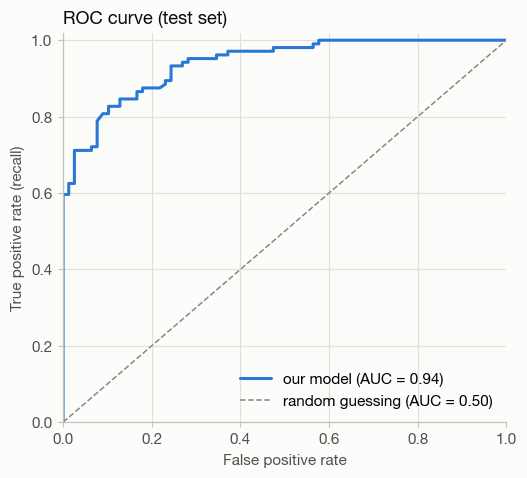

In [25]:
fpr, tpr, _ = roc_curve(test["has_5g"], prob_test)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot(fpr, tpr, color=BLUE, label=f"our model (AUC = {class_metrics['ROC-AUC']:.2f})")
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--", label="random guessing (AUC = 0.50)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title("ROC curve (test set)")
ax.legend(loc="lower right")
save(fig, "t3_05_roc_curve")
plt.show()

- **Accuracy 0.857:** we classify 85.7% of the test phones correctly, against 57.1% if we always answered "Yes".
- **Precision 0.898:** when our model says "5G", it is right 89.8% of the time.
- **Recall 0.846:** our model finds 84.6% of the 5G phones.
- **F1-score 0.871:** both precision and recall are high.
- **ROC-AUC 0.939:** if we take a random 5G phone and a random phone without 5G, our model gives the 5G phone the higher probability 93.9% of the time. Unlike the other metrics, it doesn't depend on our 0.5 cut-off. Our ROC curve is far above the diagonal of random guessing.

**Where does our model make mistakes?** The most confident wrong answers on the test set:

In [26]:
mistakes = test.assign(probability=prob_test, predicted=np.where(pred_label == 1, "Yes", "No"))
mistakes = mistakes[mistakes["predicted"] != mistakes["has_5g_label"]]
cols = ["model", "price_eur", "processor_speed", "refresh_rate", "has_5g_label", "predicted", "probability"]
(pd.concat([mistakes[mistakes["predicted"] == "Yes"].nlargest(4, "probability"),
            mistakes[mistakes["predicted"] == "No"].nsmallest(4, "probability")])[cols]
   .rename(columns={"has_5g_label": "has 5G", "probability": "P(5G = Yes)"})
   .style.format({"price_eur": "€{:,.0f}", "processor_speed": "{:.2f}", "P(5G = Yes)": "{:.3f}"}).hide(axis="index"))

model,price_eur,processor_speed,refresh_rate,has 5G,predicted,P(5G = Yes)
Motorola Moto G60,€178,2.30,120,No,Yes,0.760
Samsung Galaxy Note 10 Plus,€656,2.73,60,No,Yes,0.726
Infinix Note 12 VIP,€222,2.05,120,No,Yes,0.637
Xiaomi Redmi Note 11 Pro 4G,€200,2.05,120,No,Yes,0.624
Realme Q3i 5G,€122,2.20,60,Yes,No,0.129
Honor X8 5G,€167,2.20,60,Yes,No,0.143
Vivo Y55 5G,€233,2.20,60,Yes,No,0.165
OPPO F21s Pro,€288,2.20,60,Yes,No,0.186


Our model's mistakes make sense:
- **False "Yes":** phones that look modern but have no 5G. The Samsung Galaxy Note 10 Plus is an expensive flagship from 2019, before 5G was common. The Motorola Moto G60, the Infinix Note 12 VIP and the Redmi Note 11 Pro 4G are 4G phones with fast 120 Hz screens.
- **False "No":** cheap 5G phones with simple 60 Hz screens, like the Realme Q3i 5G, the Honor X8 5G and the Vivo Y55 5G.

Our data has no release date. A phone's age would probably explain many of these mistakes.

## B.6 Probability predictions for new phones (requirement 5)
We describe five new phones and let our model predict the probability that each one has 5G. If the probability is at least 0.5, the answer is "Yes", otherwise "No".

In [27]:
new_phones_5g = pd.DataFrame({
    "phone": ["Budget phone, 60 Hz screen", "Budget phone, 90 Hz screen", "Budget phone, 120 Hz screen",
              "Mid-range phone, 90 Hz screen", "Premium phone, 120 Hz screen"],
    "price_eur": [120, 120, 120, 230, 450],
    "processor_speed": [2.0, 2.0, 2.0, 2.3, 3.0],
    "refresh_rate": [60, 90, 120, 90, 120],
})
new_phones_5g["price_100eur"] = new_phones_5g["price_eur"] / 100
new_phones_5g["P(5G = Yes)"] = log_model.predict(new_phones_5g)
new_phones_5g["prediction"] = np.where(new_phones_5g["P(5G = Yes)"] >= 0.5, "Yes", "No")
(new_phones_5g.drop(columns="price_100eur")
    .style.format({"price_eur": "€{:,.0f}", "processor_speed": "{:.1f}", "P(5G = Yes)": "{:.3f}"}).hide(axis="index"))

phone,price_eur,processor_speed,refresh_rate,P(5G = Yes),prediction
"Budget phone, 60 Hz screen",€120,2.0,60,0.078,No
"Budget phone, 90 Hz screen",€120,2.0,90,0.239,No
"Budget phone, 120 Hz screen",€120,2.0,120,0.539,Yes
"Mid-range phone, 90 Hz screen",€230,2.3,90,0.493,No
"Premium phone, 120 Hz screen",€450,3.0,120,0.979,Yes


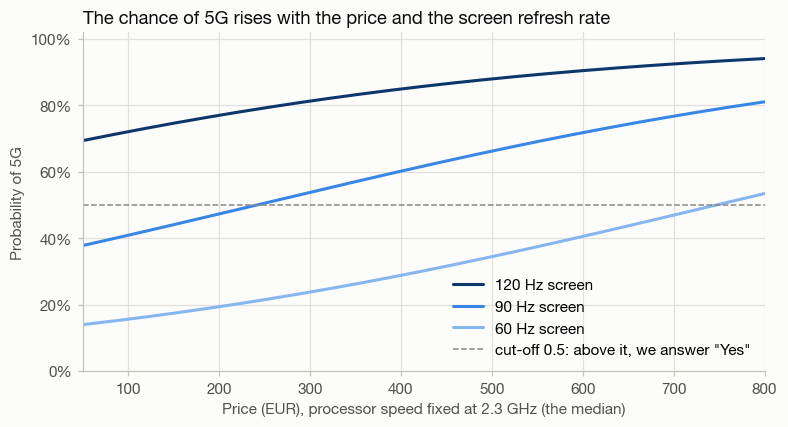

In [28]:
speed = df["processor_speed"].median()
prices = np.linspace(50, 800, 200)
fig, ax = plt.subplots(figsize=(8, 4))
# Light to dark blue: the darker the line, the faster the screen
for hz, color in [(120, "#0d366b"), (90, "#3987e5"), (60, "#86b6ef")]:
    grid = pd.DataFrame({"price_100eur": prices / 100, "processor_speed": speed, "refresh_rate": hz})
    ax.plot(prices, log_model.predict(grid), color=color, label=f"{hz} Hz screen")
ax.axhline(0.5, color=MUTED, linewidth=1, linestyle="--", label="cut-off 0.5: above it, we answer \"Yes\"")
ax.set_xlabel(f"Price (EUR), processor speed fixed at {speed:.1f} GHz (the median)")
ax.set_ylabel("Probability of 5G")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(50, 800); ax.set_ylim(0, 1.02)
ax.set_title("The chance of 5G rises with the price and the screen refresh rate")
ax.legend(loc="lower right")
save(fig, "t3_06_5g_probability")
plt.show()

- A typical **budget phone** (€120, 2.0 GHz, 60 Hz screen) has only a **7.8%** chance of 5G → "No".
- The **same budget phone** with a 90 Hz screen: 23.9% → still "No". With a 120 Hz screen: **53.9% → "Yes"**.
- A **mid-range phone** (€230, 2.3 GHz, 90 Hz) is a coin flip: 49.3%, just below the cut-off → "No".
- A **premium phone** (€450, 3.0 GHz, 120 Hz) almost surely has 5G: **97.9% → "Yes"**.

The chart shows the same for all prices: the chance of 5G rises with the price, and phones with faster screens get there much sooner. With the median processor speed (2.3 GHz), the answer turns to "Yes" at about €240 for a phone with a 90 Hz screen, but only at about €750 with a 60 Hz screen. With a 120 Hz screen, the answer is "Yes" at any price.

## B.7 Conclusion of Part B

**Which phones get 5G?** Our binary logistic regression:

p = P(5G = Yes) = 1 / (1 + e^−(−11.0486 + 0.2605 · price_100eur + 2.8131 · processor_speed + 0.0439 · refresh_rate))

- The chance of 5G rises with the **price**, the **processor speed** and the **screen refresh rate**. All three coefficients are significant (z-tests, every p ≤ 0.004), and so is the whole model (likelihood ratio test, p < 0.001), at α = 0.05.
- On new phones, the model is right **86%** of the time (vs 57% for always saying "Yes"), finds **85%** of the 5G phones, and has an **ROC-AUC of 0.94**.
- Its mistakes are mostly older or 4G phones that look modern, and cheap 5G phones with simple screens.

Together with Task 2 (Test 6), this tells us that **5G is not about the brand, but about how expensive and how modern a phone is**.

# Summary of Task 3

| | Part A: linear regression | Part B: logistic regression |
|---|---|---|
| Question | What drives the price of a phone? | Which phones get 5G? |
| Dependent variable | log(price in €) | 5G: "Yes" or "No" |
| Predictors | processor speed, RAM, storage, NFC, iPhone, foldable | price, processor speed, screen refresh rate |
| Significance (α = 0.05) | all 6 t-tests and the F-test: p < 0.001 | all 3 z-tests (p ≤ 0.004) and the likelihood ratio test (p < 0.001) |
| Results on the test set | R² = 0.83, MAE = €81, RMSE = €145, MAPE = 25% | accuracy 0.86, precision 0.90, recall 0.85, F1 0.87, ROC-AUC 0.94 |
| Main finding | with the same specs, an iPhone costs 2.5× and a foldable 2.0× as much | the chance of 5G rises with the price, the chip speed and the screen refresh rate |

**Our story across the three tasks:**
- *Task 1:* the price is skewed, and it goes with the processor speed, RAM and storage. 5G and NFC are features of more expensive phones.
- *Task 2:* for most phones you pay for the specs, but iPhones cost more for lower spec scores, and flagships give little extra for twice the price.
- *Task 3:* our models put numbers on this. Six variables explain 83% of the variation in log price on new phones, and with the same specs an iPhone costs 2.5 times as much as an Android phone. And whether a phone gets 5G depends on how expensive and modern it is, not on its brand.